In [1]:
#other imports
import os
import numpy as np
import scipy as sp
import pickle
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec
from AnalysisManagerEncoding import AnalysisManagerEncoding as analysisenc

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
#decoded_variables= {'choice', 'shuffled/choice'}#{'sound_category','shuffled/sound_category', 'choice', 'shuffled/choice','outcome','shuffled/outcome'}
decoded_variables= { 'photostim', 'shuffled/photostim'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed
data_handler_pass = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #testing with all datasets

# remove_indices = [8,22] #NO SOUND/CHOICE
#remove_indices = [24] #[2,8,11,22,23,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)
#remove_indices = [2,7,8,20,21,22] #NO OUTCOME

##remove_indices =  [0,1,3,4,5,6,7,9,10,12,13,14,15,16,17,18,19,20,21,22,24]#[24] #NO PHOTOSTIM (CONTROL MOUSE)


#remove_indices = [0,1,2,4,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] testing with 2 datasets
remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22] #testing with 1 dataset

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA10-1L', '2023-03-31', 'V:')
('HE1-00', '2023-05-30', 'V:')


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []
cat_results_pass = []

model_type = 'GLM_3nmf_pre'
results_pre,results_pre_all_sb, cat_results, celltype_info = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop

model_type = 'GLM_3nmf_passive'
results_pass,results_pass_all_sb, cat_results_pass, celltype_info = data_handler_pass.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA10-1L_2023-03-31
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/1_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/2_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/3_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/4_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/5_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/6_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA10-1L/2023-03-31/GLM_3nmf_pre/decoding/7_1/
decoder_r

In [6]:
def save_process_multiple_datasets_output(output, filename):
    """
    Save the output of process_multiple_datasets to a file using pickle.
    
    Parameters:
    - output: The output of process_multiple_datasets
    - filename: str, the filename to save the output
    """
    with open(filename, 'wb') as file:
        pickle.dump(output, file)
    print(f"Output saved to {filename}")


def load_all_pickles_from_directory(directory):
    """
    Load all pickled files from a given directory.
    
    Parameters:
    - directory: str, the directory to search for pickled files
    
    Returns:
    - dict: A dictionary where keys are filenames (without .pkl extension) and values are the loaded data
    """
    data_dict = {}
    
    # Iterate over all files in the directory
    for filename in os.listdir(directory):
        if filename.endswith('.pkl'):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'rb') as file:
                data = pickle.load(file)
                # Use the filename without the .pkl extension as the key
                key = os.path.splitext(filename)[0]
                data_dict[key] = data
                print(f"Data loaded from {filename}")
    
    return data_dict

In [7]:
# import pickle
# #save as pickled files so we can load them faster?
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre.pkl'))
# save_process_multiple_datasets_output(results_pre, os.path.join(save_results,'choice,' 'results_pre_all_sb.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass.pkl'))
# save_process_multiple_datasets_output(results_pass, os.path.join(save_results, 'results_pass_all_sb.pkl'))
#save_process_multiple_datasets_output(cat_results, os.path.join(save_results,'choice,' 'cat_results.pkl'))
# save_process_multiple_datasets_output(cat_results_pass, os.path.join(save_results,'choice,' 'cat_results_pass.pkl'))
# save_process_multiple_datasets_output(celltype_info, os.path.join(save_results,'choice,' 'celltype_info.pkl'))


In [8]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)
#initialize analysis class from encoding bc we are using the same functions
analysisenc = analysisenc(data = None, plotter = plotter)

In [9]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [10]:
# Get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)
print(list(decoded_variables)[1])
shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[1], metric = 'sc_instantaneous_information')
if 'photostim' in decoded_variables or 'sound_category' in decoded_variables:
    shuffled_structure_pass = data_handler_pass.create_shuffled_distribution_structure(decoder_type = list(decoded_variables)[1], metric = 'sc_instantaneous_information')


photostim
HA10-1L_2023-03-31
HE1-00_2023-05-30
HA10-1L_2023-03-31
HE1-00_2023-05-30


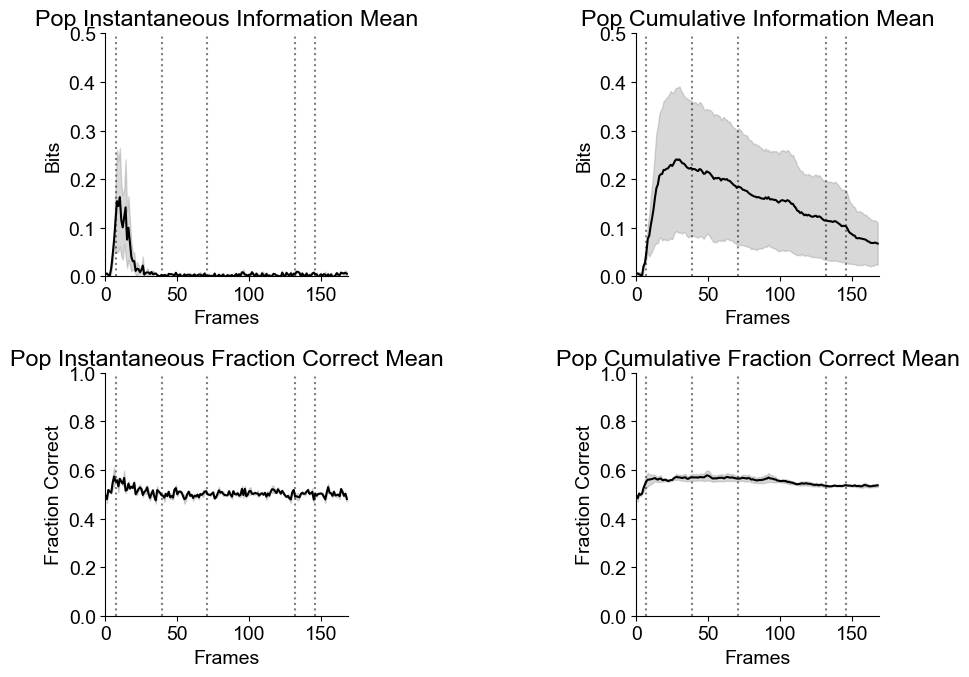

In [11]:
# Plot population decoders across datasets
current_model_type = 'test'
results_pre_all = results_pre_all_sb 
current_decoder_type = list(decoded_variables)[1] #'choice'   
os.makedirs(f'{plotter.save_results}/{current_model_type}/', exist_ok=True)

# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop', # or sc
                     save_dir= None, #f'{plotter.save_results}/{current_model_type}', #,save_dir = f'{save_results}/{current_decoder_type}_{current_model_type}_pop'
                     xlim = None, #(0,100)
                     ylim = [0.5, 0.5, 1, 1]) #define y limits for each subplot

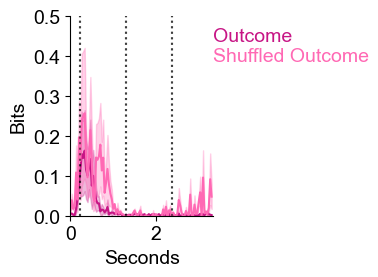

Bonferroni corrected alpha threshold: 0.05000


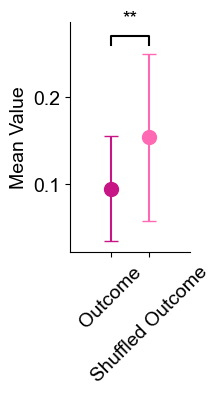

([0.0042724609375], [0.0042724609375])

In [12]:
# List of mean_results and corresponding decoder types
mean_results_list = [results_pre_all_sb, results_pass_all_sb]
decoder_types = ['photostim','photostim'] #['outcome', 'shuffled/outcome']

# Plot population decoders across datasets
current_model_type = 'test'#'pre' or passive
data_type = 'information'# 'fraction_correct' or 'information'
if data_type == 'information':
    ylabel = 'Bits'
else:
    ylabel = 'Fraction Correct'
current_decoder_type = decoder_types[0]
save_dir_contexts = f'{plotter.save_results}/{current_model_type}_instantaneous_{data_type}_{current_decoder_type}'
# results_pre_all = results_pre_all_sb 

labels = ['Outcome','Shuffled Outcome'] #['Active', 'Passive']
colors_used =  ['mediumvioletred','hotpink']#['steelblue','lightskyblue'] #['saddlebrown','darkorange'] #['darkslateblue','mediumslateblue'] #colors for the bar plot     
frames_used = np.arange(7,22) #frames to plot in the bar/scatter plot
os.makedirs(save_dir_contexts , exist_ok=True)


# Plot the selected metric and get concatenated means and SEMs
concatenated_means, concatenated_sems = plotter.plot_selected_metric_with_sem(mean_results_list, decoder_types, 
                                                                      metric=f'pop_instantaneous_{data_type}_mean', 
                                                                      title= None, 
                                                                      xlabel='Seconds', 
                                                                      ylabel= ylabel, #'SC Metric 1 Value',
                                                                      ylim = (0,.5),
                                                                      xlim = (0,100), #in terms of frames (30 frames = 1 second)
                                                                    save_dir=None,#save_dir_contexts,
                                                                    labels = labels,
                                                                    colors = colors_used)


# create bar or scatter plot of mean values at specific range of values
plotter.simple_plot_wrapper(labels, concatenated_means, concatenated_sems,plot_type = 'scatter', colors= colors_used, frames = frames_used, ylabel = 'Mean Value', save_dir = None)


In [13]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec(celltype_info)

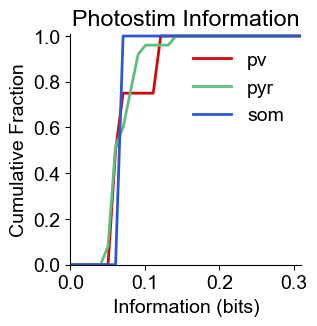

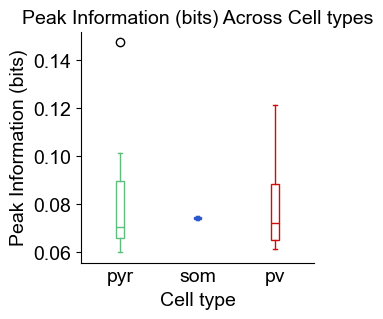

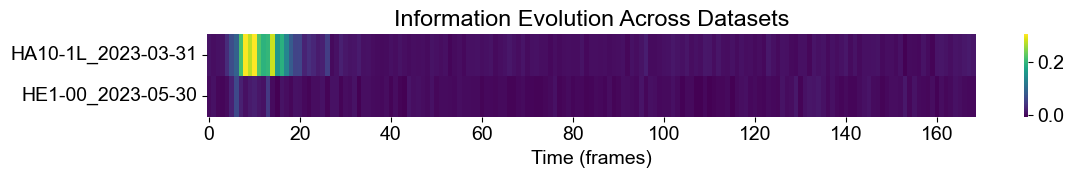

Cell type: pyr, Number of significant neurons: 25
Cell type: som, Number of significant neurons: 2
Cell type: pv, Number of significant neurons: 4
Cell type: all, Number of significant neurons: 31


In [14]:
#DECIDE WHETHER OR NOT TO USE END FRAME
current_model_type = 'test'
current_decoder_type = 'photostim' 
results_pre_all = results_pre_all_sb
start_frame = 14 #14 before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold =  0.06 #use threshold OR percentile to decide signficant neurons
method ='range_threshold'# 'shuffled_peak', 'threshold_peak', 'range_threshold'
metric_to_plot = 'sc_instantaneous_information_mean'

# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')
save_path = f'{plotter.save_results}/{current_model_type}{start_frame}{current_decoder_type}/'
os.makedirs(save_path , exist_ok=True)

peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure, method = method,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 95, threshold = threshold) #, end_frame = 100

#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!

cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=True)

#cdf
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title='Photostim Information',
                                xlabel = 'Information (bits)',
                                xval=.3,
                                xint=0.1,
                                save_path=f'{save_path}{current_decoder_type}_cdf_thr{threshold_str}.svg')

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)',
    save_path=f'{save_path}{current_decoder_type}_box_plot_thr{threshold_str}.png'
)

#heatmap across datasets
plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')

# PRINT OUT # OF SIGNIFICANT NEURONS PER CELL TYPE
# Assuming cdf_data is a dictionary with cell types as keys and peaks as values
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')


In [15]:
test
import seaborn as sns
def plot_summary_heatmap( results_dict, decoder_type, start_frame=14, end_frame=None, metric='sc_cumulative_information_mean', significant_neurons=None, save_path = None):
    """Plot a summary heatmap combining all datasets, normalized by each neuron's maximum value."""
    combined_data = []
    if end_frame is None:
            end_frame = len(data)

    overall_size = round(end_frame - start_frame)

    # Determine plot size based on overall_size
    if overall_size < 100:
        figsize = (3, 3)
    elif 100 <= overall_size < 200:
        figsize = (4, 3)
    elif 200 <= overall_size < 300:
        figsize = (5, 3)
    else:
        figsize = (6, 3)

    plt.figure(figsize=figsize)

    for dataset in results_dict:
        data = results_dict[dataset][decoder_type][metric] #data is frames x neurons
        event_frames = results_dict[dataset][decoder_type]['event_frame_mean']
        

        # Use only significant neurons if they exist
        if significant_neurons is not None and dataset in significant_neurons and len(significant_neurons[dataset]) > 0:
            neuron_mask = np.isin(np.arange(data.shape[1]), significant_neurons[dataset])
            data = data[:, neuron_mask]

        # Normalize each neuron by its maximum value
        data = data[start_frame:end_frame, :]
        max_values = np.max(data, axis=0) #gives neurons
        normalized_data = data / max_values  # Normalize by Imax for each neuron
        combined_data.append(normalized_data)

    # Combine all datasets along the neuron axis
    if combined_data:
        combined_data = np.concatenate(combined_data, axis=1)
    
        # Sort neurons by their peak frame across all datasets
        peak_frames = np.argmax(combined_data, axis=0)
        sort_idx = np.argsort(peak_frames)[::-1] #[::-1] to reverse it
        combined_data = combined_data[:, sort_idx]

        # Convert x-axis from frames to seconds
        num_frames = data.shape[1]
        time_in_seconds = np.arange(num_frames) / 30.0  # 30 frames per second
        
        #print(round(int(np.floor(np.shape(combined_data)[1]*.25)),0))
        print(f'Sig neurons total {np.shape(combined_data)[1]}')

        # Plot the summary heatmap
        sns.heatmap(combined_data.T, cmap='viridis', xticklabels=time_in_seconds, yticklabels= 100) #int(np.floor(np.shape(combined_data)[1]*.2))
        #plt.title('Summary Neuron Performance (Normalized)')
        plt.xlabel('Frames')
        plt.ylabel('Neurons')
        plt.tight_layout()
        # Clean up the appearance
        ax = plt.gca()  # get current axis  
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        #ax.set_xticklabels(rotation=0)
        # Add event markers
        
        xlim = (0, np.shape(combined_data)[0]) # full trace
        for frame in event_frames:
            if frame < xlim[1]:
                ax.axvline(x=frame, color='w', linestyle=':', alpha=1)
        
    else:
        print("No data to plot in the summary heatmap.")

    # Save plot if save_path is provided
    if save_path: 
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

NameError: name 'test' is not defined

In [22]:
def visualize_single_neuron_analysis(results_dict,shuffled_structure , plotter, analyzer, decoder_type='sound_category', start_frame=14, end_frame=None, metric = 'sc_instantaneous_information_mean', significance_percentile = 95, threshold = None,method = 'shuffled_peaks', save_path=None):
    """Orchestrate single neuron analysis and visualization."""

    significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure,method, decoder_type, start_frame, end_frame,metric ,significance_percentile, threshold = threshold)
    
    #using threshold to get significant neurons? threshold_value = 0.06
    # if threshold is not None:
    #     significant_neurons_data, significance_struc = analyzer.analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame,metric,threshold)
    
    # Extract significant neurons for each dataset
    significant_neurons = {dataset: np.concatenate([significant_neurons_data[dataset][celltype] for celltype in significant_neurons_data[dataset]]) 
                           for dataset in significant_neurons_data}
    
    # Plot the heatmap, only using significant neurons if they exist
    #plotter.plot_neuron_performance_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons) #separated by datasets

    plotter.plot_significant_neurons_distribution(significance_struc,save_path=f'{save_path}_hist.svg') 

    plotter.plot_time_course_by_cell_type(results_dict, decoder_type, start_frame = 0, end_frame = end_frame, metric = metric)

    plotter.plot_summary_heatmap(results_dict, decoder_type, start_frame, end_frame, metric, significant_neurons,save_path=f'{save_path}_heatmap.svg') #combined across datasets

    plotter.plot_significant_neuron_percentages_by_celltype(significant_neurons, celltype_info,  save_path=f'{save_path}.png')

    return significant_neurons_data, significance_struc

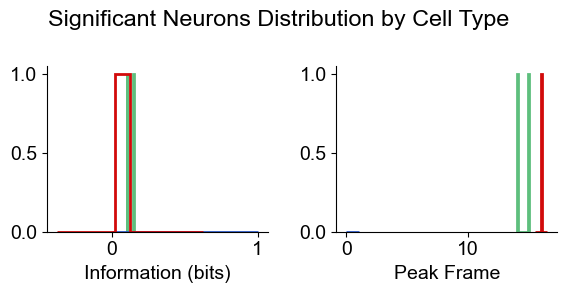

<Figure size 640x480 with 0 Axes>

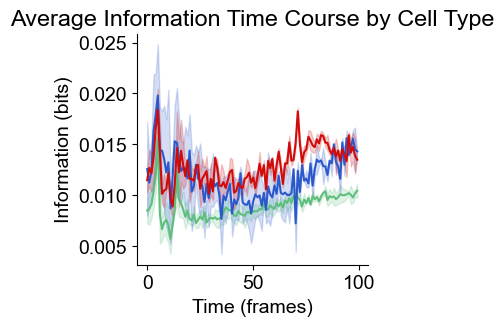

Sig neurons total 343


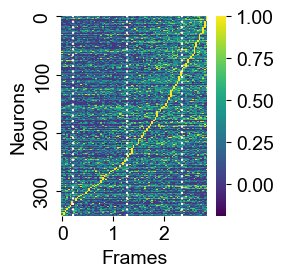

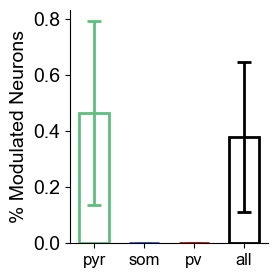

Significantly Modulated Neurons (% ± SEM):
pyr: 0.46 ± 0.33%
som: 0.00 ± 0.00%
pv: 0.00 ± 0.00%
all: 0.38 ± 0.27%


In [40]:
# Call the visualization function
threshold = 0.1
current_decoder_type = 'photostim'
significant_neurons_data, sig_struct = visualize_single_neuron_analysis(
    results_dict=results_pre_all_sb,
    shuffled_structure = shuffled_structure,
    method = 'range_threshold',
    plotter=plotter,
    analyzer =analysis_dec,
    decoder_type = current_decoder_type,  # Or your preferred decoder type
    start_frame = 14,                 # Specify start frame
    end_frame = 100,                    # Specify end frame if needed, else None
    metric = 'sc_instantaneous_information_mean', #choose sc metric to look at
    significance_percentile = 95,         #used to determine significant cells
    threshold = threshold ,                   #None or 0.06 (from Runyan 2017)
    save_path= f'{save_path}{current_decoder_type}_sig_cel_thr{str(threshold)}'
)

# # Save significant neurons data to a .mat file
# mat_file_path = os.path.join(save_path, f'significant_neurons_data_none.mat')
# sp.io.savemat(mat_file_path, significant_neurons_data)


In [162]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])

# Prepare data for saving
matlab_data = {}
for dataset, celltypes in significant_neurons_data.items():
    print(dataset)
    sanitized_dataset = sanitize_field_name(dataset)
    matlab_data[sanitized_dataset] = {}
    for celltype, indices in celltypes.items():
        sanitized_celltype = sanitize_field_name(celltype)
        
        if indices is None:
            peaks = [peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_values'][index] for index in indices]
            # Add one to each index for MATLAB indexing
            indices = [index + 1 for index in indices]
        matlab_data[sanitized_dataset][sanitized_celltype] = {
            'indices': indices,
            'peaks': peaks
        }
# # Prepare data for saving
# matlab_data = {}
# for dataset, celltypes in significant_neurons_data.items():
#     sanitized_dataset = sanitize_field_name(dataset)
#     matlab_data[sanitized_dataset] = {}
#     for celltype, data in celltypes.items():
#         sanitized_celltype = sanitize_field_name(celltype)
#         matlab_data[sanitized_dataset][sanitized_celltype] = [index + 1 for index in indices]  # Save indices of significant neurons 

# Save significant neurons data to a .mat file
mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, matlab_data)
print(f'Significant neurons data saved to {mat_file_path}')

HA11-1R_2023-05-05
HA11-1R_2023-04-13
HA2-1L_2023-04-12
HA2-1L_2023-05-05
HA1-00_2023-06-29
HA1-00_2023-08-28
HE4-1L1R_2023-08-21
HE4-1L1R_2023-08-24
HA10-1L_2023-04-17
HA10-1L_2023-04-12
HA11-1R_2023-04-07
HA11-1R_2023-05-01
HA11-1R_2023-05-02
HA2-1L_2023-04-28
HA2-1L_2023-05-01
HA1-00_2023-06-27
HA1-00_2023-07-07
HA1-00_2023-08-25
HE4-1L1R_2023-08-14
HE4-1L1R_2023-08-28
HE4-1L1R_2023-09-04
HA10-1L_2023-03-31
HE1-00_2023-05-30
Significant neurons data saved to V:/Connie/results/glm_decoding/prelim/passive/significant_neurons_data.mat


In [192]:
np.shape(significant_neurons_data['HA11-1R_2023-05-05']['pyr'])

(228,)

In [117]:
# Function to sanitize field names for MATLAB
def sanitize_field_name(name):
    return ''.join(['_' if not c.isalnum() and c != '_' else c for c in name])
# Print the number of significant neurons per cell type and prepare data for saving
significant_neurons_data = {}
for cell_type, data in cdf_data.items():
    if 'peaks' in data:
        num_significant_neurons = len(np.array(data['peaks']))
        print(f'Cell type: {cell_type}, Number of significant neurons: {num_significant_neurons}')
        sanitized_cell_type = sanitize_field_name(cell_type)
        significant_neurons_data[sanitized_cell_type] = {
            'num_significant_neurons': num_significant_neurons,
            'peaks': np.array(data['peaks'])
        }

mat_file_path = os.path.join(save_path, 'significant_neurons_data.mat')
sp.io.savemat(mat_file_path, significant_neurons_data)

Cell type: pyr, Number of significant neurons: 3837
Cell type: som, Number of significant neurons: 212
Cell type: pv, Number of significant neurons: 406
Cell type: all, Number of significant neurons: 4455


In [ ]:
start_frame = 14 #before this there is artifact
end_frame = 100 #100 for sound/photostim
threshold = None #use threshold OR percentile to decide signficant neurons
# Replace dot with underscore in threshold for directory name
threshold_str = str(threshold).replace('.', '_')

results_dict=results_pre_all
plotter=plotter
analyzer =analysis_dec
decoder_type = current_decoder_type  # Or your preferred decoder type
start_frame = 14                 # Specify start frame
end_frame = 100                  # Specify end frame if needed, else None
metric = 'sc_instantaneous_information_mean' #choose sc metric to look at
significance_percentile = 95         #used to determine significant cells


peaks_by_celltype_test = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure_pass,
                                                            decoder_type=current_decoder_type, start_frame=start_frame , end_frame = end_frame,
                                                            significance_percentile = 95, threshold = threshold) #, end_frame = 100


significant_neurons_data_test, significance_struc = analyzer.analyze_significant_neurons(results_dict,shuffled_structure_pass, decoder_type, start_frame, end_frame,metric ,significance_percentile)

In [233]:
def analyze_significant_neurons_test( results_dict, shuffled_structure, decoder_type, start_frame, end_frame, metric='sc_instantaneous_information_mean', significance_percentile=95, threshold = None):
    """Analyze significant neurons for plotting."""
    neuron_ids_by_dataset = {}
    significance_struc = {}
    peaks_by_celltype = analyzer.analyze_peaks_by_celltype(results_dict, shuffled_structure, decoder_type, start_frame, end_frame, significance_percentile, threshold)

    for dataset in results_dict:
        neuron_ids_by_dataset[dataset] = {}
        significance_struc[dataset] = {}
        
        for celltype in peaks_by_celltype[dataset]:
            neuron_ids_by_dataset[dataset][celltype] = []

            # Ensure initialization of significance_struc[dataset][celltype]
            significance_struc[dataset][celltype] = {}
            # Extract significant neurons
            significant_neurons = peaks_by_celltype[dataset][celltype]['sc'][metric]['significant_neurons']
            neuron_ids_by_dataset[dataset][celltype] = np.where(significant_neurons)[0].tolist()
            print(f"[analyze_significant_neurons] Dataset: {dataset}, Celltype: {celltype}, Significant Neurons: {neuron_ids_by_dataset[dataset][celltype]}")
            # Add peak data for significant neurons
            significant_indices = neuron_ids_by_dataset[dataset][celltype]
            significance_struc[dataset][celltype]['peak_values'] = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_values'][significant_indices]
            significance_struc[dataset][celltype]['peak_frames'] = peaks_by_celltype[dataset][celltype]['sc'][metric]['peak_frames'][significant_indices]
            print(f"[analyze_significant_neurons] Dataset: {dataset}, Celltype: {celltype}, Peak Values: {significance_struc[dataset][celltype]['peak_values']}")

    return neuron_ids_by_dataset, significance_struc

neuron_ids_by_dataset_test, significance_struc_test = analyze_significant_neurons_test(results_dict, shuffled_structure_pass, decoder_type, start_frame, end_frame, metric, significance_percentile, threshold = 0.1)    

[analyze_significant_neurons] Dataset: HA11-1R_2023-05-05, Celltype: pyr, Significant Neurons: [1, 13, 14, 18, 25, 26, 31, 34, 37, 42, 49, 56, 62, 65, 76, 77, 79, 80, 82, 87, 88, 90, 92, 98, 103, 108, 111, 112, 127, 141, 146, 165, 172, 181, 191, 193, 198, 203, 214, 215, 226, 227, 229, 232, 237, 244, 257, 260, 261, 263, 268, 271, 287, 294, 295, 300, 305, 314, 315, 318, 326]
[analyze_significant_neurons] Dataset: HA11-1R_2023-05-05, Celltype: pyr, Peak Values: [0.10423688 0.1126506  0.10572008 0.14128084 0.13036414 0.12220593
 0.10872464 0.18937827 0.11950315 0.18436243 0.20521085 0.11910133
 0.10184481 0.143469   0.10196266 0.15610707 0.14405931 0.1080673
 0.10199751 0.11199777 0.11482599 0.11626036 0.12646852 0.11063549
 0.10761787 0.10196266 0.11799908 0.10468631 0.10054916 0.1084134
 0.11310003 0.10775606 0.18958304 0.10613466 0.10037611 0.10789547
 0.11799908 0.14033314 0.18533529 0.10185932 0.14843769 0.15421626
 0.12182858 0.11524057 0.20622369 0.12251718 0.10199751 0.10178961
 0.

In [239]:
def analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame, metric='sc_instantaneous_information_mean', threshold=0.5):
        """Analyze significant neurons by threshold, looping through cell types defined in self.cell_types."""
        neuron_ids_by_dataset = {}
        significance_struc = {}

        for dataset in results_dict:
            neuron_ids_by_dataset[dataset] = {}
            significance_struc[dataset] = {}

            # Get the indices for neurons of this cell type
            celltype_array = analyzer.celltype_data[dataset]['celltype_array']
            # Get indices for each cell type
            celltype_indices = {
                'pyr': np.where(celltype_array == 0)[0],
                'som': np.where(celltype_array == 1)[0],
                'pv': np.where(celltype_array == 2)[0]
            }

            data = results_dict[dataset][decoder_type][metric]

            if end_frame is None:
                end_frame = data.shape[0]

            # Extract the data within the specified frames
            data_in_range = data[start_frame:end_frame, :]

            # Loop through cell types defined in self.cell_types
            for celltype, indices in celltype_indices.items(): #for celltype in self.cell_types:
                neuron_ids_by_dataset[dataset][celltype] = []
                significance_struc[dataset][celltype] = {}

                
                celltype_indices = indices  # Assuming this is a list/array of indices

                if len(celltype_indices) == 0:
                    continue  # Skip if no neurons of this cell type

                # Subset the data for the current cell type
                data_celltype = data_in_range[:, celltype_indices]
                

                # Find neurons that exceed the threshold at any point in the range
                significant_neurons = np.any(data_celltype > threshold, axis=0)
                neuron_ids = np.array(celltype_indices)[np.where(significant_neurons)[0]].tolist()
                print(neuron_ids)
                neuron_ids_by_dataset[dataset][celltype] = neuron_ids

                # Collect additional information for the significant neurons
                significance_struc[dataset][celltype]['peak_values'] = np.max(data_celltype[:, significant_neurons], axis=0)
                significance_struc[dataset][celltype]['peak_frames'] = np.argmax(data_celltype[:, significant_neurons], axis=0) + start_frame

        return neuron_ids_by_dataset, significance_struc

neuron_ids_by_dataset_test, significance_struc_test = analyze_significant_neurons_by_threshold(results_dict, decoder_type, start_frame, end_frame, metric, threshold = 0.1) 

[23, 39, 40, 45, 53, 54, 60, 64, 67, 73, 83, 90, 96, 99, 111, 114, 117, 118, 120, 125, 126, 128, 130, 137, 142, 147, 150, 151, 167, 185, 190, 210, 217, 228, 239, 241, 246, 251, 263, 264, 275, 276, 278, 282, 287, 297, 312, 315, 316, 318, 323, 326, 344, 351, 353, 358, 363, 372, 373, 376, 384]
[172, 300]
[0, 2, 6, 9, 13, 15, 16, 18, 19, 20, 26, 37, 38, 59, 74, 81, 103, 112, 163, 225]
[15, 17, 19, 20, 24, 25, 26, 29, 41, 43, 50, 58, 66, 72, 73, 78, 80, 83, 85, 87, 88, 104, 108, 123, 138, 140, 144, 164, 166, 171, 172, 191, 195, 199, 210, 212, 218, 234, 236, 241, 248, 257, 260, 263, 272, 276, 280, 292, 297, 298, 301, 302, 312, 313, 319, 320, 329, 331, 335, 337, 357, 360, 361, 366, 368, 370, 375, 377, 378]
[]
[0, 3, 5, 6, 8, 9, 12, 13, 49, 63, 70, 141, 305, 380]
[17, 20, 31, 32, 44, 51, 129, 145, 179, 184, 188, 197, 205, 213, 232, 233, 260, 266, 268, 274, 287, 293, 299, 301, 308, 310, 336, 347, 349, 371]
[370]
[5, 7, 80, 111, 324]
[21, 22, 27, 28, 30, 35, 42, 44, 58, 59, 66, 69, 72, 87, 112, 